In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to [0,1]
x_train, x_test = x_train / 255.0, x_test / 255.0
subset_size = 1000
x_train = x_train[:subset_size]
y_train = y_train[:subset_size]

x_test = x_train[:100]
y_test = y_train[:100]

# Convert labels to categorical (one-hot encoding)
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)


In [3]:
def create_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')  # Output layer with 10 classes
    ])
    
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create and inspect model
cnn_model = create_cnn()
cnn_model.summary()


W0220 13:58:51.037657 12252 deprecation.py:506] From C:\Users\DELL\AppData\Roaming\Python\Python36\site-packages\tensorflow\python\ops\init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 15, 15, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 13, 13, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 6, 6, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 4, 4, 128)         73856     
_________________________________________________________________
flatten (Flatten)            (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               2

Train on 1000 samples, validate on 100 samples
Epoch 1/15
1000/1000 [==============================] - 1s 609us/sample - loss: 2.2808 - acc: 0.1420 - val_loss: 2.1957 - val_acc: 0.2400
Epoch 2/15
1000/1000 [==============================] - 0s 478us/sample - loss: 2.1106 - acc: 0.2170 - val_loss: 2.0077 - val_acc: 0.2200
Epoch 3/15
1000/1000 [==============================] - 0s 456us/sample - loss: 1.9801 - acc: 0.3010 - val_loss: 1.9822 - val_acc: 0.2900
Epoch 4/15
1000/1000 [==============================] - 0s 462us/sample - loss: 1.8636 - acc: 0.3170 - val_loss: 1.7701 - val_acc: 0.3400
Epoch 5/15
1000/1000 [==============================] - 0s 469us/sample - loss: 1.7904 - acc: 0.3570 - val_loss: 1.9357 - val_acc: 0.2700
Epoch 6/15
1000/1000 [==============================] - 0s 484us/sample - loss: 1.7358 - acc: 0.3850 - val_loss: 1.7088 - val_acc: 0.4000
Epoch 7/15
1000/1000 [==============================] - 0s 483us/sample - loss: 1.6244 - acc: 0.4070 - val_loss: 1.5592 - val

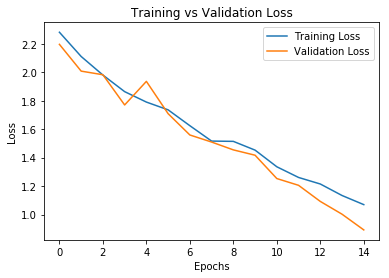

In [4]:
# Train the model
history = cnn_model.fit(x_train, y_train, epochs=15, batch_size=64,
                        validation_data=(x_test, y_test))

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


In [5]:
# Evaluate model on test set
test_loss, test_acc = cnn_model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


100/100 [==============================] - 0s 240us/sample - loss: 0.8925 - acc: 0.7500
Test Accuracy: 0.7500


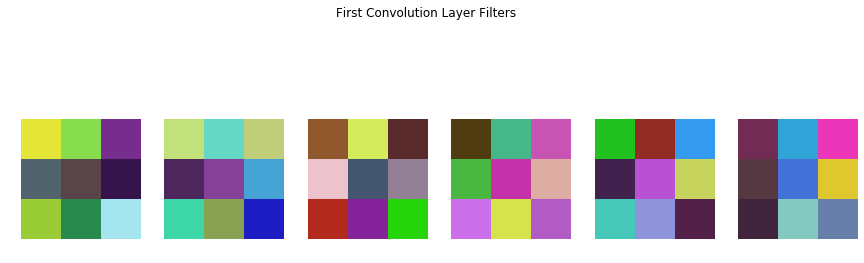

In [6]:
# Extract first convolution layer
first_conv_layer = cnn_model.layers[0]
filters, biases = first_conv_layer.get_weights()

# Normalize filter values for visualization
filters_min, filters_max = filters.min(), filters.max()
filters = (filters - filters_min) / (filters_max - filters_min)

# Plot first 6 filters
fig, axes = plt.subplots(1, 6, figsize=(15,5))
for i in range(6):
    ax = axes[i]
    ax.imshow(filters[:, :, :, i], cmap='gray')
    ax.axis('off')
plt.suptitle("First Convolution Layer Filters")
plt.show()


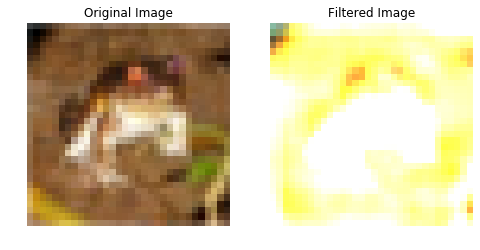

In [7]:
from scipy.ndimage import convolve

# Select an image and a filter
image = x_test[0]  # First test image
filter_idx = 0  # First filter
selected_filter = filters[:, :, :, filter_idx]

# Apply filter to each channel and combine
filtered_image = np.zeros_like(image)
for c in range(3):  # RGB channels
    filtered_image[:, :, c] = convolve(image[:, :, c], selected_filter[:, :, c])

# Normalize for display
filtered_image = np.clip(filtered_image, 0, 1)

# Plot original vs filtered image
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(filtered_image)
ax[1].set_title("Filtered Image")
ax[1].axis('off')

plt.show()


Train on 1000 samples, validate on 100 samples
Epoch 1/15
1000/1000 [==============================] - 0s 273us/sample - loss: 2.4729 - acc: 0.1330 - val_loss: 2.2380 - val_acc: 0.1200
Epoch 2/15
1000/1000 [==============================] - 0s 184us/sample - loss: 2.1811 - acc: 0.1840 - val_loss: 2.2432 - val_acc: 0.1600
Epoch 3/15
1000/1000 [==============================] - 0s 173us/sample - loss: 2.0517 - acc: 0.2450 - val_loss: 2.1506 - val_acc: 0.1900
Epoch 4/15
1000/1000 [==============================] - 0s 167us/sample - loss: 2.0183 - acc: 0.2550 - val_loss: 2.0189 - val_acc: 0.2700
Epoch 5/15
1000/1000 [==============================] - 0s 173us/sample - loss: 1.9637 - acc: 0.2850 - val_loss: 2.0730 - val_acc: 0.3100
Epoch 6/15
1000/1000 [==============================] - 0s 148us/sample - loss: 1.8773 - acc: 0.3250 - val_loss: 2.0264 - val_acc: 0.3100
Epoch 7/15
1000/1000 [==============================] - 0s 153us/sample - loss: 1.8674 - acc: 0.3300 - val_loss: 2.0128 - val

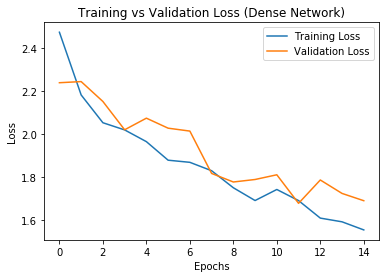

100/100 [==============================] - 0s 90us/sample - loss: 1.6888 - acc: 0.4000
Test Accuracy (Dense Network): 0.4000


In [8]:
def create_dense_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')  # Output layer
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create dense network and train
dense_model = create_dense_model()
dense_history = dense_model.fit(x_train, y_train, epochs=15, batch_size=64,
                                validation_data=(x_test, y_test))

# Plot training vs validation loss for dense network
plt.plot(dense_history.history['loss'], label='Training Loss')
plt.plot(dense_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss (Dense Network)')
plt.show()

# Evaluate dense network on test data
test_loss, test_acc = dense_model.evaluate(x_test, y_test)
print(f"Test Accuracy (Dense Network): {test_acc:.4f}")
